In [2]:
from itertools import product
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


V2_2_ROOT = Path(
    "/shared/data_zfs/blue2959/ND_Aligner/experiments/v2.2"
)

EXPERIMENT_ROOTS = {
    "Conv1d": (
        V2_2_ROOT
        / "conv1d_rf_sweep"
        / "confirm"
    ),
    "TCD": (
        V2_2_ROOT
        / "TCD_rf_sweep"
        / "confirm"
    ),
}

OUTPUT_PDF = (
    V2_2_ROOT
    / "conv1d_tcd_rf_interaction.pdf"
)

OUTPUT_PNG = (
    V2_2_ROOT
    / "conv1d_tcd_rf_interaction.png"
)

SCORER_RFS = [1, 13]
DECODER_RFS = [1, 5, 9, 13, 17]
SEEDS = [1234, 1235, 1236]

DIR_PATTERN = re.compile(
    r"^conv_RF=(?P<scorer_rf>\d+)_"
    + r"dec_RF=(?P<decoder_rf>\d+)_"
    + r"seed=(?P<seed>\d+)$"
)

In [3]:
def load_experiment_results(
    decoder_type: str,
    root_dir: Path,
) -> pd.DataFrame:
    if not root_dir.exists():
        raise FileNotFoundError(
            f"실험 디렉터리가 없습니다: {root_dir}"
        )

    records = []

    for experiment_dir in sorted(root_dir.iterdir()):
        if not experiment_dir.is_dir():
            continue

        match = DIR_PATTERN.fullmatch(
            experiment_dir.name
        )

        # conv_RF=l2 등은 자동으로 제외됨
        if match is None:
            continue

        scorer_rf = int(
            match.group("scorer_rf")
        )
        decoder_rf = int(
            match.group("decoder_rf")
        )
        seed = int(
            match.group("seed")
        )

        if scorer_rf not in SCORER_RFS:
            continue

        if decoder_rf not in DECODER_RFS:
            continue

        if seed not in SEEDS:
            continue

        metric_path = (
            experiment_dir
            / "eval_metrics.csv"
        )

        if not metric_path.exists():
            print(
                "[경고] eval_metrics.csv 없음:",
                experiment_dir.name,
            )
            continue

        metric_df = pd.read_csv(metric_path)

        required_columns = {
            "word_boundary_error",
            "p_word_25ms",
        }

        missing_columns = (
            required_columns
            - set(metric_df.columns)
        )

        if missing_columns:
            raise ValueError(
                f"{metric_path}에 필요한 열이 없습니다: "
                f"{sorted(missing_columns)}"
            )

        if metric_df.empty:
            print(
                f"[경고] 비어 있는 CSV: {metric_path}"
            )
            continue

        if len(metric_df) > 1:
            print(
                f"[경고] {experiment_dir.name}: "
                f"row가 {len(metric_df)}개이므로 "
                "마지막 row를 사용합니다."
            )

        row = metric_df.iloc[-1]

        records.append(
            {
                "decoder_type": decoder_type,
                "scorer_rf": scorer_rf,
                "decoder_rf": decoder_rf,
                "seed": seed,

                # CSV에서는 WBE가 초 단위
                "wbe_ms": (
                    float(
                        row["word_boundary_error"]
                    )
                    * 1000.0
                ),

                # 이미 percentage 단위
                "p25": float(
                    row["p_word_25ms"]
                ),
            }
        )

    return pd.DataFrame(records)

In [4]:
result_frames = []

for decoder_type, root_dir in (
    EXPERIMENT_ROOTS.items()
):
    decoder_result_df = (
        load_experiment_results(
            decoder_type=decoder_type,
            root_dir=root_dir,
        )
    )

    result_frames.append(
        decoder_result_df
    )

result_df = pd.concat(
    result_frames,
    ignore_index=True,
)

result_df = (
    result_df
    .sort_values(
        [
            "decoder_type",
            "scorer_rf",
            "decoder_rf",
            "seed",
        ]
    )
    .reset_index(drop=True)
)

display(result_df)

print(
    f"불러온 결과 수: {len(result_df)}"
)

,decoder_type,scorer_rf,decoder_rf,seed,wbe_ms,p25
0,Conv1d,1,1,1234,26.397835,67.701679
1,Conv1d,1,1,1235,26.528781,67.648453
2,Conv1d,1,1,1236,26.239604,68.541521
3,Conv1d,1,5,1234,24.804264,71.676129
4,Conv1d,1,5,1235,24.166290,72.267568
5,Conv1d,1,5,1236,25.211195,71.634728
6,Conv1d,1,9,1234,24.077317,71.918619
7,Conv1d,1,9,1235,24.684386,71.504611
8,Conv1d,1,9,1236,24.628453,72.444999
9,Conv1d,1,13,1234,24.237795,71.877217


불러온 결과 수: 60


In [5]:
key_columns = [
    "decoder_type",
    "scorer_rf",
    "decoder_rf",
    "seed",
]


# 중복 검사
duplicate_mask = result_df.duplicated(
    subset=key_columns,
    keep=False,
)

if duplicate_mask.any():
    print("[오류] 중복된 결과가 있습니다.")

    display(
        result_df.loc[
            duplicate_mask
        ].sort_values(key_columns)
    )

    raise ValueError(
        "중복된 실험 결과를 확인해주세요."
    )


# 기대하는 전체 조합
expected_df = pd.DataFrame(
    product(
        EXPERIMENT_ROOTS.keys(),
        SCORER_RFS,
        DECODER_RFS,
        SEEDS,
    ),
    columns=key_columns,
)

observed_df = (
    result_df[key_columns]
    .drop_duplicates()
)

missing_df = (
    expected_df
    .merge(
        observed_df,
        on=key_columns,
        how="left",
        indicator=True,
    )
    .query("_merge == 'left_only'")
    .drop(columns="_merge")
)

if not missing_df.empty:
    print("[오류] 누락된 실험 조합:")

    display(missing_df)

    raise ValueError(
        "필요한 실험 결과가 모두 존재하지 않습니다."
    )

print("중복 및 누락 없음")
print(f"예상 결과 수: {len(expected_df)}")
print(f"실제 결과 수: {len(result_df)}")

중복 및 누락 없음
예상 결과 수: 60
실제 결과 수: 60


In [6]:
summary_df = (
    result_df
    .groupby(
        [
            "decoder_type",
            "scorer_rf",
            "decoder_rf",
        ],
        as_index=False,
    )
    .agg(
        seed_count=("seed", "nunique"),

        wbe_mean=("wbe_ms", "mean"),
        wbe_std=("wbe_ms", "std"),

        p25_mean=("p25", "mean"),
        p25_std=("p25", "std"),
    )
    .sort_values(
        [
            "decoder_type",
            "scorer_rf",
            "decoder_rf",
        ]
    )
    .reset_index(drop=True)
)

if not (
    summary_df["seed_count"] == len(SEEDS)
).all():
    raise ValueError(
        "세 seed가 모두 포함되지 않은 설정이 있습니다."
    )

display(
    summary_df.round(
        {
            "wbe_mean": 3,
            "wbe_std": 3,
            "p25_mean": 3,
            "p25_std": 3,
        }
    )
)

,decoder_type,scorer_rf,decoder_rf,seed_count,wbe_mean,wbe_std,p25_mean,p25_std
0,Conv1d,1,1,3,26.389,0.145,67.964,0.501
1,Conv1d,1,5,3,24.727,0.527,71.859,0.354
2,Conv1d,1,9,3,24.463,0.336,71.956,0.471
3,Conv1d,1,13,3,24.234,0.285,72.124,0.268
4,Conv1d,1,17,3,24.508,0.634,71.696,1.075
5,Conv1d,13,1,3,21.919,0.186,70.809,0.404
6,Conv1d,13,5,3,21.821,0.188,70.748,0.275
7,Conv1d,13,9,3,24.207,0.609,68.967,0.536
8,Conv1d,13,13,3,25.603,0.344,65.841,0.884
9,Conv1d,13,17,3,27.810,0.686,61.044,1.158


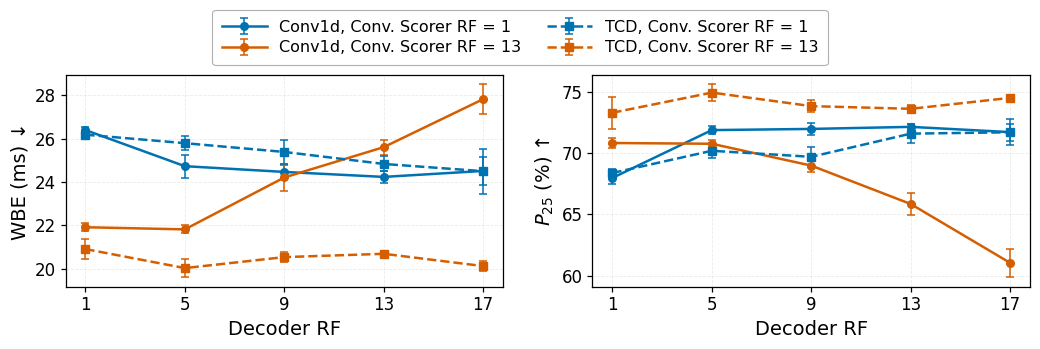

PDF 저장 완료: /shared/data_zfs/blue2959/ND_Aligner/experiments/v2.2/conv1d_tcd_rf_interaction.pdf
PNG 저장 완료: /shared/data_zfs/blue2959/ND_Aligner/experiments/v2.2/conv1d_tcd_rf_interaction.png


In [18]:
AXIS_LABEL_SIZE = 14
TICK_LABEL_SIZE = 12
LEGEND_SIZE = 11.5


fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10.5, 3.2),
    sharex=True,
)

metric_specs = [
    {
        "ax": axes[0],
        "mean_column": "wbe_mean",
        "std_column": "wbe_std",
        "ylabel": "WBE (ms) ↓",
    },
    {
        "ax": axes[1],
        "mean_column": "p25_mean",
        "std_column": "p25_std",
        "ylabel": r"$P_{25}$ (%) ↑",
    },
]


# 색상은 Scorer RF를 나타냄
scorer_colors = {
    1: "#0072B2",
    13: "#D55E00",
}

# 선과 marker는 Decoder 종류를 나타냄
decoder_styles = {
    "Conv1d": {
        "linestyle": "-",
        "marker": "o",
    },
    "TCD": {
        "linestyle": "--",
        "marker": "s",
    },
}


for decoder_type in ["Conv1d", "TCD"]:
    for scorer_rf in SCORER_RFS:
        line_df = (
            summary_df[
                (
                    summary_df["decoder_type"]
                    == decoder_type
                )
                & (
                    summary_df["scorer_rf"]
                    == scorer_rf
                )
            ]
            .sort_values("decoder_rf")
        )

        line_label = (
            f"{decoder_type}, "
            f"Conv. Scorer RF = {scorer_rf}"
        )

        style = decoder_styles[
            decoder_type
        ]

        for spec in metric_specs:
            ax = spec["ax"]

            ax.errorbar(
                x=line_df["decoder_rf"],
                y=line_df[
                    spec["mean_column"]
                ],
                yerr=line_df[
                    spec["std_column"]
                ],
                label=line_label,
                color=scorer_colors[
                    scorer_rf
                ],
                linestyle=style[
                    "linestyle"
                ],
                marker=style["marker"],
                markersize=5.5,
                linewidth=1.8,
                elinewidth=1.1,
                capsize=3.0,
                capthick=1.1,
                zorder=3,
            )

for spec in metric_specs:
    ax = spec["ax"]

    ax.set_xlabel(
        "Decoder RF",
        fontsize=AXIS_LABEL_SIZE,
    )

    ax.set_ylabel(
        spec["ylabel"],
        fontsize=AXIS_LABEL_SIZE,
    )

    ax.set_xticks(DECODER_RFS)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=TICK_LABEL_SIZE,
        color="black",
        width=0.9,
    )

    ax.grid(
        axis="both",
        linestyle="--",
        linewidth=0.6,
        alpha=0.25,
        zorder=0,
    )

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.9)

handles, labels = (
    axes[0].get_legend_handles_labels()
)

legend = fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.10),
    ncol=2,
    frameon=True,
    fancybox=True,
    framealpha=1.0,
    facecolor="white",
    edgecolor="#B0B0B0",
    fontsize=LEGEND_SIZE,
    columnspacing=1.6,
    handlelength=2.8,
    borderpad=0.6,
    labelspacing=0.35,
)

legend.get_frame().set_linewidth(0.8)
fig.tight_layout(
    rect=(0, 0, 1, .92)
)


fig.savefig(
    OUTPUT_PDF,
    bbox_inches="tight",
)

fig.savefig(
    OUTPUT_PNG,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"PDF 저장 완료: {OUTPUT_PDF}")
print(f"PNG 저장 완료: {OUTPUT_PNG}")